In [1]:
import os
import re
import cv2
import torch
from torch.utils.data import Dataset
import numpy as np

import pandas as pd
from PIL import Image


## Load Data


In [2]:
data_path = "data"

folders_dict = {}

for folder_name in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder_name)
    if os.path.isdir(folder_path):
        path_list = []
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.relpath(os.path.join(data_path, root, file), data_path)
                path_list.append(file_path)
        
        folders_dict[folder_name] = path_list

## Build dataframe of all available images and masks

In [3]:
image_data = []

for folder_name, path_list in folders_dict.items():
    for file_path in path_list:

        if folder_name == 'Defect_images':
            image_name = os.path.basename(file_path)
            mask_name = image_name.replace('.png', '_mask.png')
            mask_path = os.path.join(data_path, 'Mask_images', mask_name)

            if os.path.exists(mask_path):
                image_data.append({"image_path": file_path, "mask_path": mask_path})
            else:
                print(f"Warning: Mask file for {image_name} not found.")
        
        elif folder_name == 'NODefect_images':
            image_data.append({"image_path": file_path, "mask_path": None})

df = pd.DataFrame(image_data)

def extract_codes(file_path):
    file_name = file_path.split("\\")[-1]
    match = re.match(r"(\d{4})_(\d{3})_(\d{2})\.png", file_name)
    if match:
        return  match.group(3), match.group(2)
    else:
        return None, None

# Define the defect code to name mapping
defect_code_dict = {
    0: 'OK',
    2: 'Broken end',
    6: 'Broken yarn',
    10: 'Broken pick',
    16: 'Weft curling',
    19: 'Fuzzyball',
    22: 'Cut selvage',
    23: 'Crease',
    25: 'Warp ball',
    27: 'Knots',
    29: 'Contamination',
    30: 'Nep',
    36: 'Weft crack'
}

df['fabric_code'], df['defect_code'] = zip(*df['image_path'].apply(lambda file_path: extract_codes(file_path)))
df['defect_name'] = df['defect_code'].map(lambda x: defect_code_dict[int(x)])

In [4]:
# Define the defect code to name mapping
defect_code_dict = {
    0: 'OK',
    2: 'Broken end',
    6: 'Broken yarn',
    10: 'Broken pick',
    16: 'Weft curling',
    19: 'Fuzzyball',
    22: 'Cut selvage',
    23: 'Crease',
    25: 'Warp ball',
    27: 'Knots',
    29: 'Contamination',
    30: 'Nep',
    36: 'Weft crack'
}

# Replace defect codes with names in the DataFrame
df['defect_name'] = df['defect_code'].map(lambda x: defect_code_dict.get(int(x), x))

In [5]:
df

,image_path,mask_path,fabric_code,defect_code,defect_name
0,data\Defect_images\0001_002_00.png,data\Mask_images\0001_002_00_mask.png,00,002,Broken end
1,data\Defect_images\0002_002_00.png,data\Mask_images\0002_002_00_mask.png,00,002,Broken end
2,data\Defect_images\0003_002_00.png,data\Mask_images\0003_002_00_mask.png,00,002,Broken end
3,data\Defect_images\0004_002_01.png,data\Mask_images\0004_002_01_mask.png,01,002,Broken end
4,data\Defect_images\0005_002_01.png,data\Mask_images\0005_002_01_mask.png,01,002,Broken end
...,...,...,...,...,...
238,data\NODefect_images\2608691-202020u\0016_000_...,None,01,000,OK
239,data\NODefect_images\2608691-202020u\0017_000_...,None,01,000,OK
240,data\NODefect_images\2608691-202020u\0018_000_...,None,01,000,OK
241,data\NODefect_images\2608691-202020u\0019_000_...,None,01,000,OK


In [6]:
def unique_defect_id(df):
    defect_code_to_id = {'000': 0}
    non_zero_defect_codes = [code for code in df['defect_code'].unique() if code != '000']
    # idx + 1 to save 0 for background (000)
    defect_code_to_id.update({code: idx + 1 for idx, code in enumerate(non_zero_defect_codes)})
    df.loc[:, 'defect_id'] = df['defect_code'].map(defect_code_to_id)

    return df
unique_defect_id(df)

,image_path,mask_path,fabric_code,defect_code,defect_name,defect_id
0,data\Defect_images\0001_002_00.png,data\Mask_images\0001_002_00_mask.png,00,002,Broken end,1
1,data\Defect_images\0002_002_00.png,data\Mask_images\0002_002_00_mask.png,00,002,Broken end,1
2,data\Defect_images\0003_002_00.png,data\Mask_images\0003_002_00_mask.png,00,002,Broken end,1
3,data\Defect_images\0004_002_01.png,data\Mask_images\0004_002_01_mask.png,01,002,Broken end,1
4,data\Defect_images\0005_002_01.png,data\Mask_images\0005_002_01_mask.png,01,002,Broken end,1
...,...,...,...,...,...,...
238,data\NODefect_images\2608691-202020u\0016_000_...,None,01,000,OK,0
239,data\NODefect_images\2608691-202020u\0017_000_...,None,01,000,OK,0
240,data\NODefect_images\2608691-202020u\0018_000_...,None,01,000,OK,0
241,data\NODefect_images\2608691-202020u\0019_000_...,None,01,000,OK,0


## Dataset Analysis


In [7]:
import matplotlib.pyplot as plt


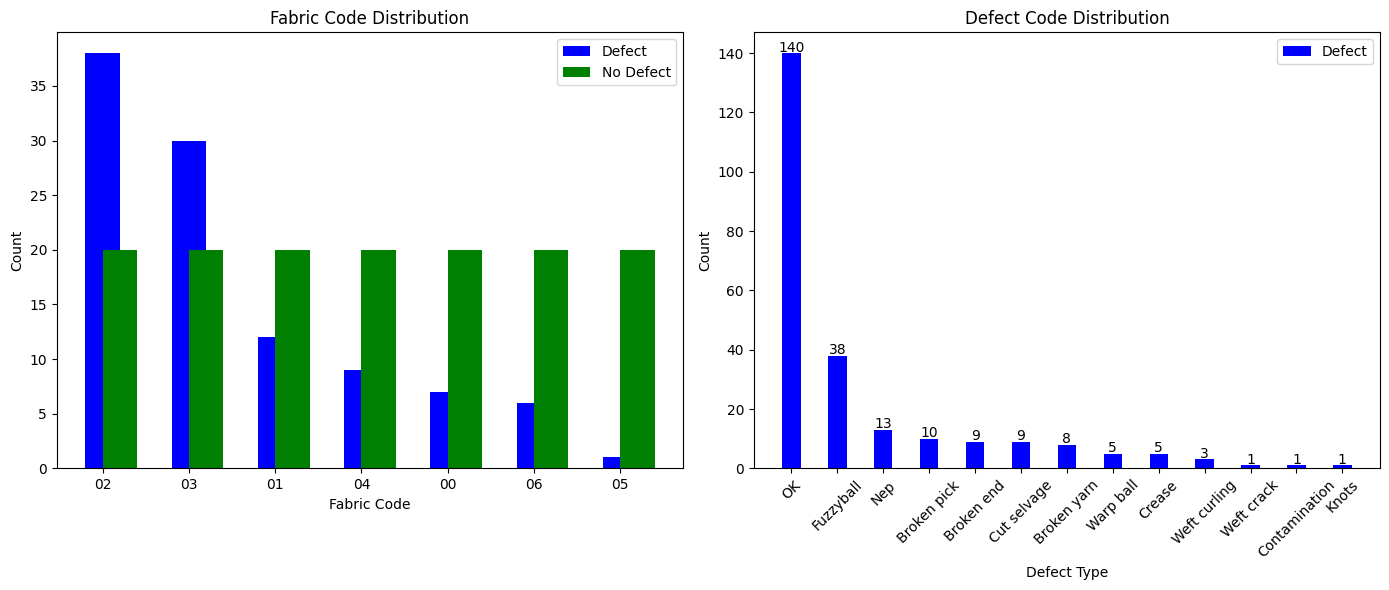

In [8]:
# Filter Defect_images and NODefect_images
defect_df = df[df['defect_code'] != '000']
nodf_df = df[df['defect_code'] == '000']

# Create a subplot with two graphs
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot fabric code distribution for Defect_images and NODefect_images
fabric_defect_count = defect_df['fabric_code'].value_counts()
fabric_nodf_count = nodf_df['fabric_code'].value_counts()


# Plot fabric code distribution for Defect_images and NODefect_images
ax[0].bar(fabric_defect_count.index, fabric_defect_count.values, color='blue', label='Defect', width=0.4, align='center')
ax[0].bar(fabric_nodf_count.index, fabric_nodf_count.values, color='green', label='No Defect', width=0.4, align='edge')


ax[0].set_title('Fabric Code Distribution')
ax[0].set_xlabel('Fabric Code')
ax[0].set_ylabel('Count')
ax[0].legend()

# Plot defect code distribution for Defect_images only
defect_count = df['defect_name'].value_counts()

ax[1].bar(defect_count.index, defect_count.values, color='blue', label='Defect', width=0.4, align='center')

# Add count numbers on top of the bars
for i, value in enumerate(defect_count.values):
    ax[1].text(i, value + 0.5, str(value), ha='center', fontsize=10)

ax[1].set_title('Defect Code Distribution')
ax[1].set_xlabel('Defect Type')
ax[1].set_ylabel('Count')
ax[1].legend()
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

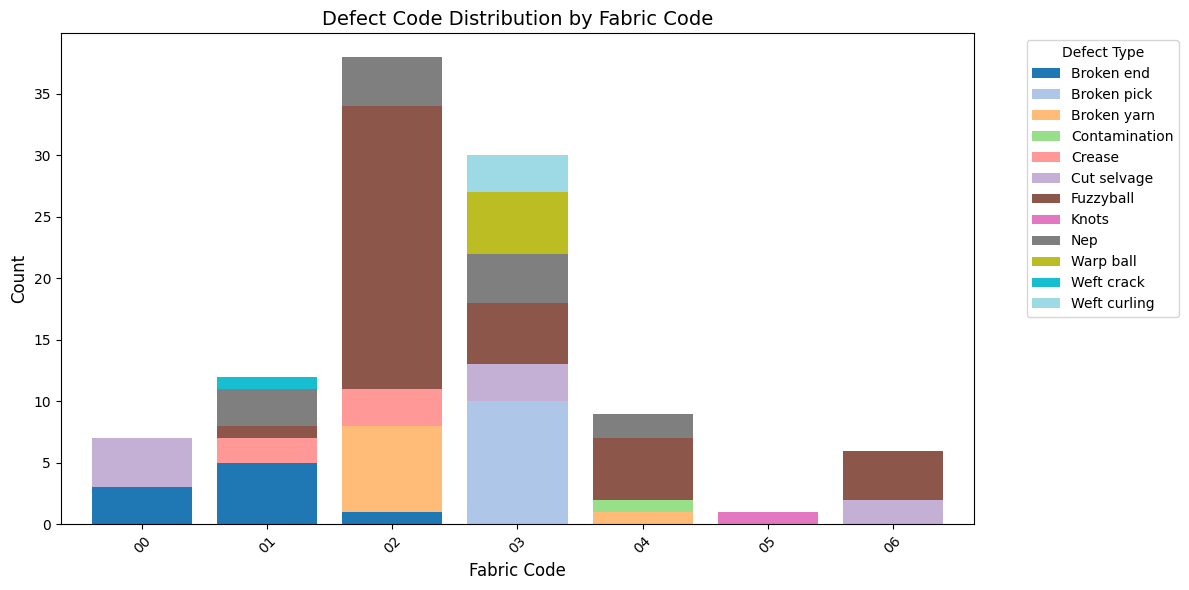

In [9]:
# Count defect names per fabric code
defect_counts = defect_df.groupby(['fabric_code', 'defect_name']).size().unstack(fill_value=0)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the stacked bars with different colors for each defect name
defect_counts.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.8)

# Set the title and labels
ax.set_title('Defect Code Distribution by Fabric Code', fontsize=14)
ax.set_xlabel('Fabric Code', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Rotate x-axis labels for readability
ax.tick_params(axis='x', rotation=45)

# Show the legend (defect names)
ax.legend(title='Defect Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

## Preprocessing

In [58]:
class CustomImageDataset(Dataset):
    def __init__(self, data_df, transform=None, target_transform=None):
        self.data = data_df
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        image = cv2.imread(row["image_path"])
        
        if row["mask_path"]:
            mask = cv2.imread(row["mask_path"])
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

        meta = {
            "Defect_code": row["defect_code"],
            "Defect_name": row["defect_name"],
            "Defect_id": row["defect_id"],
            "Fabric_code": row["fabric_code"],
        }
        
        if self.transform:
            image, mask, meta = self.transform(image, mask, meta)

        return image, mask, meta
    
    
    def downsample(self, n_samples):
        """
        Returns a CustomImageDataset with n_samples  of each defect class
        Parameters:
            n_samples (int): Number of samples to keep per group.

        Returns:
            CustomImageDataset: A new dataset with the downsampled data.
        """
        grouped = self.data.groupby("defect_id")
        downsampled_data = grouped.apply(lambda x: x.sample(n=min(n_samples, len(x)))).reset_index(drop=True)
        return CustomImageDataset(downsampled_data, transform=self.transform)
    
# filter top 6 defects
top_6_defects = df['defect_code'].value_counts().head(6).index  
filtered_df = df[df['defect_code'].isin(top_6_defects)]
filtered_df = unique_defect_id(filtered_df)
    
all_ds = CustomImageDataset(filtered_df)

In [61]:
all_ds[0][1].shape

(256, 4096, 3)

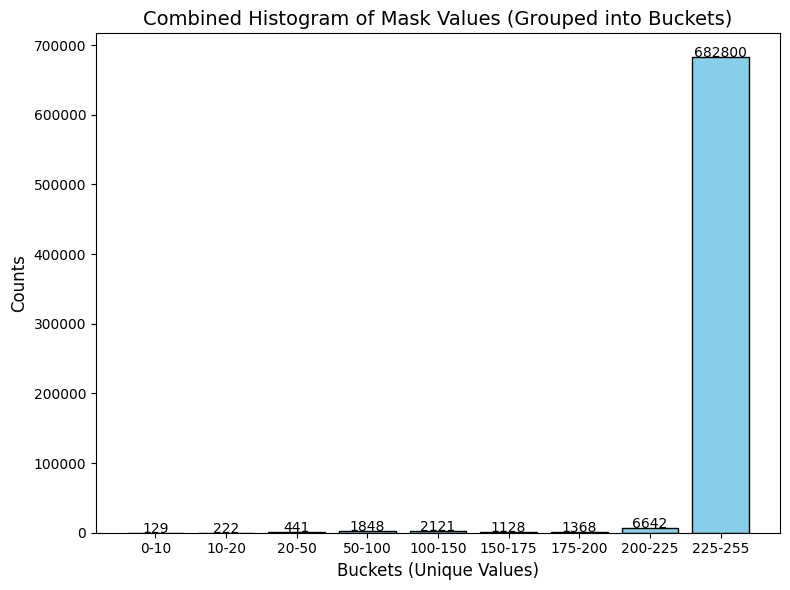

In [52]:
bins = [0, 10, 20, 50, 100, 150,175, 200, 225, 255] 
global_counts = np.zeros(len(bins) - 1, dtype=int)

for idx in range(len(all_ds)):
    mask = all_ds[idx][1]  
    unique_values, counts = np.unique(mask, return_counts=True)
    unique_values = unique_values[1:]  # Exclude background 
    counts = counts[1:]  

    # Group counts into buckets and add to global counts
    bucket_indices = np.digitize(unique_values, bins, right=True)
    for i in range(1, len(bins)):
        global_counts[i - 1] += np.sum(counts[bucket_indices == i])

# Create the histogram
plt.figure(figsize=(8, 6))
plt.bar(
    range(len(global_counts)), 
    global_counts, 
    tick_label=[f"{bins[i]}-{bins[i+1]}" for i in range(len(bins) - 1)], 
    color='skyblue', edgecolor='black'
)

# Add labels and title
plt.xlabel('Buckets (Unique Values)', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title('Combined Histogram of Mask Values (Grouped into Buckets)', fontsize=14)

# Optional: Show exact counts above bars
for i, count in enumerate(global_counts):
    plt.text(i, count + 0.5, str(count), ha='center', fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

In [112]:
def draw_bbox_and_transparent_mask(image, mask, meta):
    # Ensure the mask is binary (0 or 1)
    # _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

    # Find the contours of the mask (defect area)
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Initialize an empty mask to draw on
    transparent_mask = np.zeros_like(image, dtype=np.uint8)
    
    # Draw the bounding box and fill the transparent mask with the mask
    for contour in contours:
        # Bounding box for the contour
        x, y, w, h = cv2.boundingRect(contour)
        
        # Draw the bounding box on the image (green color)
        cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # BGR (green)
        
        # Create a transparent overlay of the mask
        cv2.drawContours(transparent_mask, [contour], -1, (255, 255, 255), thickness=cv2.FILLED)
    
    # Create an overlay of the transparent mask with a transparent background
    overlay = image.copy()
    alpha = 0.7  # Transparency factor (0 to 1)
    
    # Blend the original image with the transparent mask
    cv2.addWeighted(transparent_mask, alpha, overlay, 1 - alpha, 0, overlay)
    
    return overlay, mask, meta

In [116]:
def threshold_mask(image, mask, meta):
    print(mask.shape)
    threshold_min = 200
    mask = np.where(mask >= threshold_min, 1, 0)  
    print(type(mask))
    return image, mask, meta

def apply_id_to_mask(image, mask, meta):
    print(mask.shape)
    defect_id = meta.get("Defect_id", 0)
    
    # If the mask is 3-channel, convert it to a single channel (grayscale)
    mask = mask.astype(np.float32)  # Ensure mask is uint8
    if len(mask.shape) == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    
    # Now apply the defect_id as a binary mask
    mask = mask * defect_id  # Apply the defect_id to the mask, making it binary (0 or defect_id)
    
    return image, mask, meta

def mask_normalize(image, mask, meta):
    image, mask, meta = threshold_mask(image, mask, meta)
    image, mask, meta = apply_id_to_mask(image, mask, meta)
    # image, mask, meta = draw_bbox_and_transparent_mask(image, mask, meta)
    return image, mask, meta


In [117]:
all_ds.transform = mask_normalize

In [ ]:
np.unique(all_ds[0][1], return_counts=True)

(256, 4096)
<class 'numpy.ndarray'>
(256, 4096)


(array([0.]), array([1048576]))

## Train and Test Split